# PCG - Estudo de Caso Duke Breast Cancer

Bem-vindo ao roteiro da Pesquisa Curricularizada de Graduação (PCG). Este notebook tem como objetivo realizar uma Análise Exploratória de Dados (EDA) do conjunto de dados "Duke Breast Cancer". 

Nossa missão é avaliar características demográficas, clínicas e moleculares para compreender os padrões da doença e identificar fatores preditivos de resposta ao tratamento neoadjuvante, utilizando técnicas de estatística descritiva e storytelling com dados.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para os gráficos
sns.set_theme(style='whitegrid')

# Ingestão de dados
# O parâmetro na_values força o Pandas a reconhecer os textos do dataset como valores ausentes reais (NaN)
valores_ausentes = ['NA', 'NC', 'NP', 'x', '']

df_breast_cancer = pd.read_csv(
    './Dataset/Clinical_and_Other_Features.csv', 
    sep=';', 
    header=1, 
    low_memory=False, 
    na_values=valores_ausentes
)

## 4. Inconsistências e Qualidade dos Dados

A qualidade dos dados é crucial na investigação clínica. Primeiramente, iremos quantificar os dados ausentes. Para preservar o perfil real das pacientes e não introduzir viés com imputações artificiais (como o preenchimento por médias em variáveis biológicas), a nossa estratégia será remover as linhas que possuam falhas críticas nas colunas fundamentais para este estudo. 

Em seguida, aplicaremos engenharia de atributos para converter a idade das pacientes de dias para anos.

In [3]:
# Relatório de valores nulos (Top 10 em percentual)
null_report = (df_breast_cancer.isnull().sum() / len(df_breast_cancer)) * 100
print("--- TOP 10 COLUNAS COM DADOS AUSENTES (%) ---")
print(null_report.sort_values(ascending=False).head(10))
print("\n")

# Engenharia de Atributos: Forçar a conversão para numérico antes de calcular a idade
df_breast_cancer['Date of Birth (Days)'] = pd.to_numeric(df_breast_cancer['Date of Birth (Days)'], errors='coerce')
df_breast_cancer['Age_Years'] = df_breast_cancer['Date of Birth (Days)'].abs() / 365.25

# Lista das colunas críticas com os nomes exatos do dataset
critical_columns = [
    'Age_Years',
    'Staging(Tumor Size)# [T]',
    'Staging(Nodes)#(Nx replaced by -1)[N]',
    'Mol Subtype',
    'Overall Near-complete Response:  Stricter Definition'
]

# Remoção de nulos estritamente para o escopo da pesquisa
df_breast_cancer.dropna(subset=critical_columns, inplace=True)

# Padronizar as colunas de estadiamento clínico como texto limpo.
# Isso evita que as Células 6 e 8 quebrem ao tentar ordenar os eixos dos gráficos.
df_breast_cancer['Staging(Tumor Size)# [T]'] = df_breast_cancer['Staging(Tumor Size)# [T]'].astype(str).str.replace('.0', '', regex=False)
df_breast_cancer['Staging(Nodes)#(Nx replaced by -1)[N]'] = df_breast_cancer['Staging(Nodes)#(Nx replaced by -1)[N]'].astype(str).str.replace('.0', '', regex=False)

--- TOP 10 COLUNAS COM DADOS AUSENTES (%) ---
Unnamed: 98                                               100.000000
Unnamed: 67                                               100.000000
Unnamed: 42                                                99.674973
Unnamed: 46                                                99.674973
Unnamed: 45                                                99.674973
Unnamed: 44                                                99.674973
Unnamed: 47                                                99.674973
Solid                                                      98.483207
Days to local recurrence (from the date of diagnosis)      98.266522
Mass Density                                               98.158180
dtype: float64




## 1. Contexto Geral (O Panorama da Doença)

**Pergunta 1: Como a idade das pacientes se distribui no nosso conjunto de dados e de que forma isso se relaciona com a gravidade ou o estágio do câncer no momento do diagnóstico?**

* **Como interpretar os gráficos abaixo:**
  * O **Histograma** (à esquerda) ilustra a concentração demográfica. A curva de densidade destaca a faixa etária com maior volume de diagnósticos na base.
  * O **Boxplot** (à direita) cruza os estágios do tumor primário (T) com a idade. A linha central das caixas representa a mediana de idade. Observando a posição das caixas, podemos inferir se pacientes mais jovens ou mais velhas tendem a chegar ao diagnóstico já em estágios mais avançados (como T3 e T4).

--- ESTATÍSTICA DESCRITIVA DA IDADE ---
mean    49.528538
50%     48.095825
std     11.388697
Name: Age_Years, dtype: float64


C:\Users\gumsb\AppData\Local\Temp\ipykernel_17220\1998876032.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_breast_cancer, x='Staging(Tumor Size)# [T]', y='Age_Years', order=stage_t_order, palette='Set2', ax=axes[1])


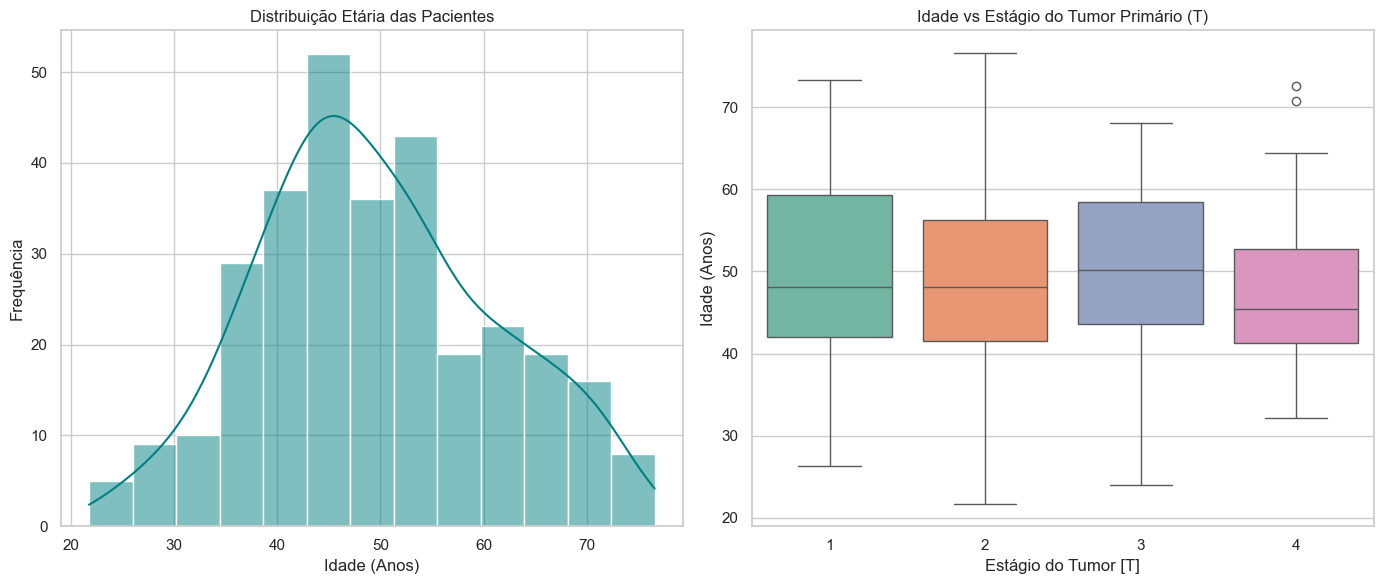

In [4]:
# Estatística descritiva básica da idade
print("--- ESTATÍSTICA DESCRITIVA DA IDADE ---")
print(df_breast_cancer['Age_Years'].describe()[['mean', '50%', 'std']])

# Criação dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma da Idade
sns.histplot(data=df_breast_cancer, x='Age_Years', kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribuição Etária das Pacientes')
axes[0].set_xlabel('Idade (Anos)')
axes[0].set_ylabel('Frequência')

# Boxplot cruzando Estágio do Tumor (T) com Idade
stage_t_order = sorted(df_breast_cancer['Staging(Tumor Size)# [T]'].unique())
sns.boxplot(data=df_breast_cancer, x='Staging(Tumor Size)# [T]', y='Age_Years', order=stage_t_order, palette='Set2', ax=axes[1])
axes[1].set_title('Idade vs Estágio do Tumor Primário (T)')
axes[1].set_xlabel('Estágio do Tumor [T]')
axes[1].set_ylabel('Idade (Anos)')

plt.tight_layout()
plt.show()

## 2. Identificação de Padrões (As Características Clínicas)

**Pergunta 2: Existe alguma relação visual clara entre o tamanho do tumor e a probabilidade de a doença ter se espalhado para os linfonodos?**

* **Como interpretar o gráfico abaixo:** 
  * O **Gráfico de Violino** relaciona o tamanho físico do tumor primário (T) no eixo X com o nível de comprometimento dos linfonodos axilares (N) no eixo Y. 
  * A "largura" do violino mostra onde os dados estão mais concentrados. Se o volume dos violinos "subir" no eixo Y conforme avançamos para a direita no eixo X, isso comprova visualmente a correlação clínica de que tumores maiores aumentam a probabilidade de disseminação linfática.

C:\Users\gumsb\AppData\Local\Temp\ipykernel_17220\1977131933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


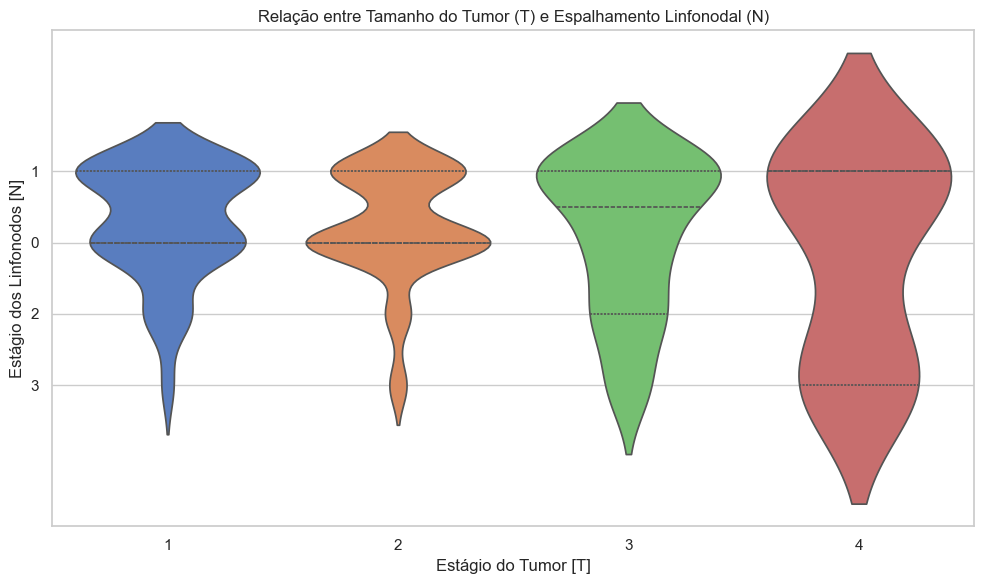

In [5]:
fig = plt.figure(figsize=(10, 6))

# Tratamento numérico temporal para N-Staging para ordenar visualmente
node_order = sorted(df_breast_cancer['Staging(Nodes)#(Nx replaced by -1)[N]'].unique())

sns.violinplot(
    data=df_breast_cancer, 
    x='Staging(Tumor Size)# [T]', 
    y='Staging(Nodes)#(Nx replaced by -1)[N]', 
    order=stage_t_order, 
    inner='quartile', 
    palette='muted'
)

plt.title('Relação entre Tamanho do Tumor (T) e Espalhamento Linfonodal (N)')
plt.xlabel('Estágio do Tumor [T]')
plt.ylabel('Estágio dos Linfonodos [N]')
plt.tight_layout()
plt.show()

## 3. Análise de Subgrupos (Os Tipos de Câncer)

**Pergunta 3: Como as informações sobre os diferentes subtipos da doença e os receptores hormonais nos ajudam a agrupar e a entender melhor o perfil das pacientes?**

* **Como interpretar o gráfico abaixo:** 
  * O gráfico de barras exibe o volume de pacientes contidas em cada subtipo molecular. 
  * O câncer de mama é uma doença heterogênea. Agrupar as pacientes é fundamental, pois cada grupo possui um nível de agressividade e uma linha de tratamento específica:
    * **Luminal A e B:** São tumores alimentados por hormônios (Estrogênio/Progesterona). O tipo A tem crescimento mais lento e melhor prognóstico, enquanto o B possui crescimento celular mais rápido.
    * **HER2 Enriched:** Tumores impulsionados pelo excesso da proteína HER2. Tendem a crescer rapidamente, mas respondem muito bem a "terapias-alvo" direcionadas a essa proteína.
    * **Triple Negative (Triplo Negativo):** Tumores que não possuem receptores hormonais nem a proteína HER2. Costumam ser os mais agressivos, pois há menos opções de terapias direcionadas, dependendo fortemente da quimioterapia tradicional.

  * *Nota Técnica:* O algoritmo a seguir decodifica as chaves numéricas originais da base (0, 1, 2, 3) e plota as nomenclaturas moleculares reais no eixo Y para corrigir distorções de escala e facilitar a leitura.

C:\Users\gumsb\AppData\Local\Temp\ipykernel_17220\593911986.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subtype_distribution.values, y=subtype_distribution.index, palette='magma')


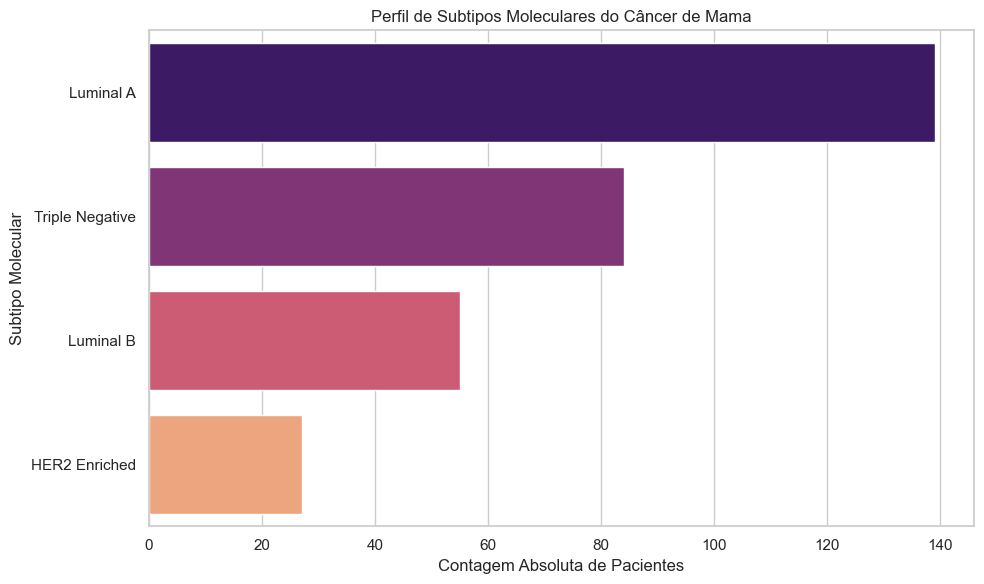

In [6]:
# Mapeamento numérico para as nomenclaturas reais dos Subtipos Moleculares
subtype_mapping = {
    0.0: 'Luminal A',
    1.0: 'Luminal B',
    2.0: 'HER2 Enriched',
    3.0: 'Triple Negative'
}

# Aplicando o mapeamento em uma nova coluna para fins de visualização
df_vis = df_breast_cancer.copy()
df_vis['Mol Subtype_Label'] = pd.to_numeric(df_vis['Mol Subtype'], errors='coerce').map(subtype_mapping).fillna('Desconhecido')

# Contagem da distribuição
subtype_distribution = df_vis['Mol Subtype_Label'].value_counts()

fig = plt.figure(figsize=(10, 6))
# Gráfico ordenado com os nomes reais no Eixo Y
sns.barplot(x=subtype_distribution.values, y=subtype_distribution.index, palette='magma')

plt.title('Perfil de Subtipos Moleculares do Câncer de Mama')
plt.xlabel('Contagem Absoluta de Pacientes')
plt.ylabel('Subtipo Molecular')
plt.tight_layout()
plt.show()

## 5. O Desfecho (O Insight Estratégico)

**Pergunta 5: Ao observar os dados históricos disponíveis, quais características iniciais parecem ser mais comuns nas pacientes que tiveram uma boa resposta aos tratamentos médicos?**

Para avaliar a eficácia terapêutica, utilizaremos a interpretação rigorosa (*Stricter Definition*), que reflete a Resposta Patológica Completa (pCR).

* **Como interpretar os gráficos abaixo:**
  * **Gráfico de Barras (Esquerda):** Permite comparar visualmente, dentro de cada subtipo molecular, a proporção de pacientes que falharam (cor azul) versus as que obtiveram sucesso (cor verde) no tratamento neoadjuvante. Subtipos onde a barra verde é proporcionalmente mais alta indicam grupos com melhor resposta inicial.
  * **Boxplot (Direita):** Compara a distribuição de idades entre as pacientes categorizadas como "0 - Não Respondeu" e "1 - Respondeu". Se a caixa das pacientes que responderam ao tratamento estiver posicionada mais para baixo, sugere-se que pacientes mais jovens tendem a apresentar desfechos favoráveis com maior frequência.

C:\Users\gumsb\AppData\Local\Temp\ipykernel_17220\1773906586.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


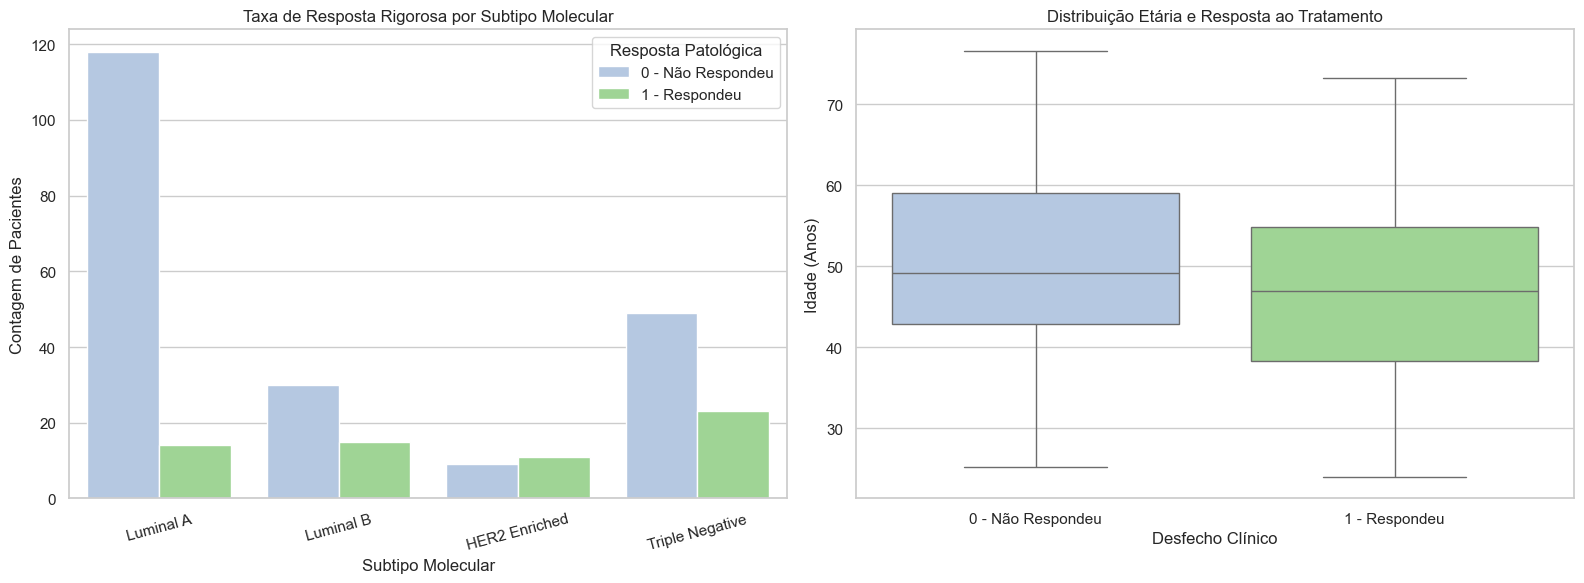

In [7]:
# Definindo a coluna alvo
target_response_col = 'Overall Near-complete Response:  Stricter Definition'

# Limpeza: Garantir que a coluna de resposta tenha apenas 0.0 e 1.0 (Removendo os outliers 2 e 3)
df_vis[target_response_col] = pd.to_numeric(df_vis[target_response_col], errors='coerce')
df_vis = df_vis[df_vis[target_response_col].isin([0.0, 1.0])]

# Criando rótulos textuais amigáveis para a variável de resposta
response_mapping = {0.0: '0 - Não Respondeu', 1.0: '1 - Respondeu'}
df_vis['Response_Label'] = df_vis[target_response_col].map(response_mapping)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ordem fixa para o eixo X dos Subtipos
subtype_order = ['Luminal A', 'Luminal B', 'HER2 Enriched', 'Triple Negative']

# 1. Countplot para Subtipos vs Resposta (Corrigido)
sns.countplot(
    data=df_vis, 
    x='Mol Subtype_Label', 
    hue='Response_Label', 
    order=subtype_order,
    palette={'0 - Não Respondeu': '#aec7e8', '1 - Respondeu': '#98df8a'}, 
    ax=axes[0]
)
axes[0].set_title('Taxa de Resposta Rigorosa por Subtipo Molecular')
axes[0].set_xlabel('Subtipo Molecular')
axes[0].set_ylabel('Contagem de Pacientes')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Resposta Patológica')

# 2. Boxplot para Resposta vs Idade (Corrigido)
sns.boxplot(
    data=df_vis, 
    x='Response_Label', 
    y='Age_Years', 
    order=['0 - Não Respondeu', '1 - Respondeu'],
    palette={'0 - Não Respondeu': '#aec7e8', '1 - Respondeu': '#98df8a'}, 
    ax=axes[1]
)
axes[1].set_title('Distribuição Etária e Resposta ao Tratamento')
axes[1].set_xlabel('Desfecho Clínico')
axes[1].set_ylabel('Idade (Anos)')

plt.tight_layout()
plt.show()

## Conclusão da Apresentação

O cruzamento da idade, dos subtipos moleculares e do tamanho inicial do tumor nos permite construir um perfil preditivo robusto. 

Através deste Storytelling de dados, observamos historicamente como as características iniciais de diagnóstico afetam de maneira drástica as taxas de resposta às terapias sistêmicas. Estas visualizações fornecem uma fundação baseada em dados reais para apoiar decisões oncológicas estratégicas e validar as hipóteses biológicas da nossa pesquisa.